In [17]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [18]:
import sys
sys.path.insert(0, "src")
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m

In [19]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

#### this is with the "refactored" python file: neoscore

In [20]:
# Initialize the scorer once with the 4D grid to use it
scorer = nsc.NEOMODScorer(array4D, H_center, a_center, e_center, i_center)

result = scorer.compute_score(
    obstime_str="2025-09-23T00:00:00",
    ra_deg=10.0, dec_deg=20.0,
    dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
    mag=24.0,
    d_au=0.2, ddot_kms=3.0
)

print(f"Score: {result['score']}")
print(f"a: {result['a']}")
print(f"e: {result['e']}")
print(f"i: {result['i']}")
print(f"H: {result['H']}")

Score: 155.21
a: 1.8147948989466396
e: 0.35850436140431774
i: 3.646480531805697
H: 26.159186480177784


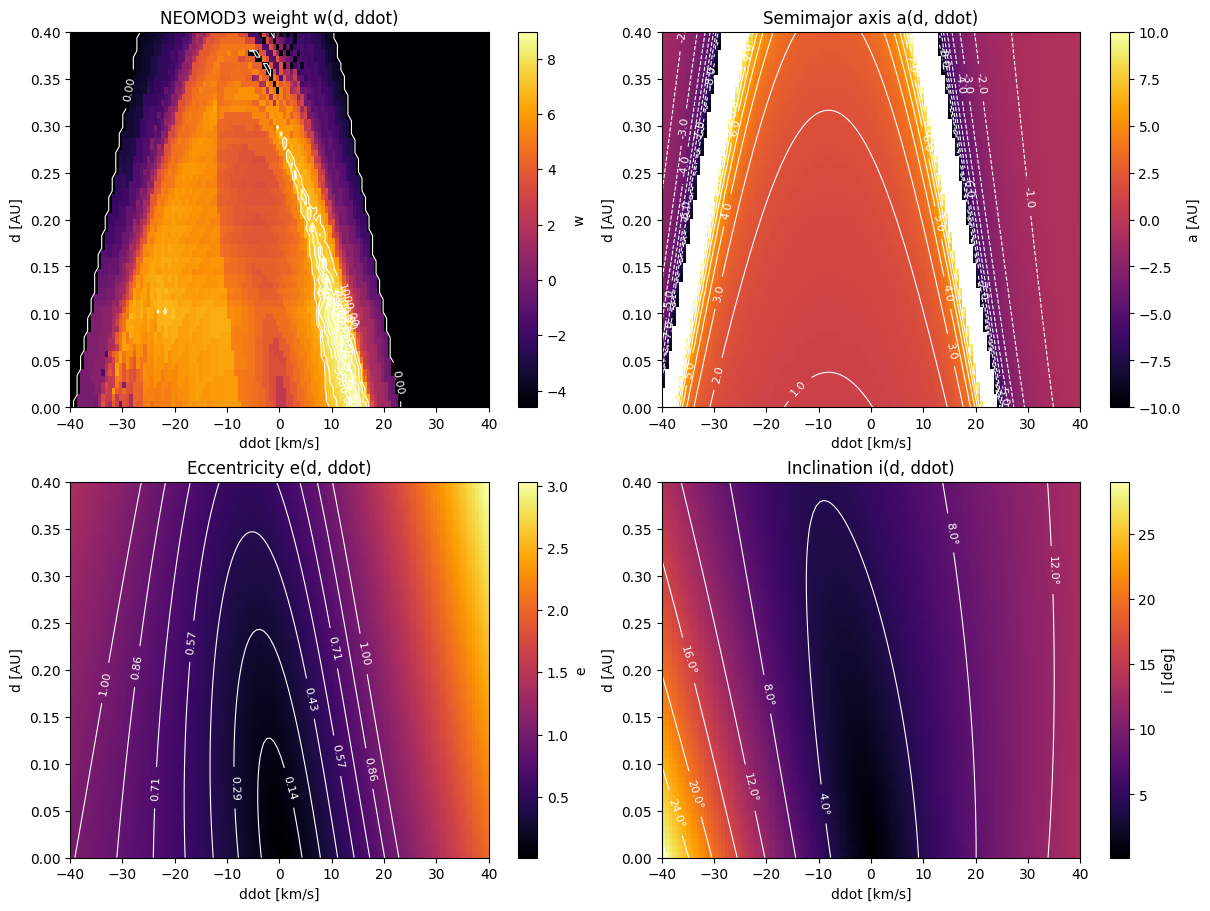

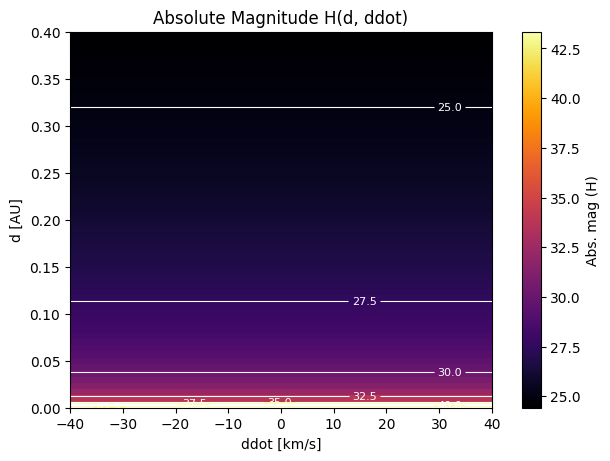

In [21]:
from matplotlib.colors import TwoSlopeNorm

# Define the grid
d_min, d_max, Nd = 0.00, 0.40, 60
v_min, v_max, Nv = -40.0, 40.0, 120
d_vals = np.linspace(d_min, d_max, Nd)
v_vals = np.linspace(v_min, v_max, Nv)

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra_deg, dec_deg = 10.0, 20.0
dra_deg_per_day, ddec_deg_per_day = 0.12, 0.22
mag = 24.0

# Computes the grids
W = np.zeros((Nd, Nv))
A = np.zeros((Nd, Nv))
E = np.zeros((Nd, Nv))
I = np.zeros((Nd, Nv))
H = np.zeros((Nd, Nv))

for i, d_au in enumerate(d_vals):
    for j, ddot_kms in enumerate(v_vals):
        result = scorer.compute_score(
            obstime_str, ra_deg, dec_deg,
            dra_deg_per_day, ddec_deg_per_day, mag,
            d_au, ddot_kms
        )
        W[i, j] = result['score']
        A[i, j] = result['a']
        E[i, j] = result['e']
        I[i, j] = result['i']
        H[i, j] = result['H']

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# Semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# Inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# Absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### this is with the old python file: NEOfaster

In [6]:
# observables
obstime_str="2025-09-23T00:00:00" # observed time in UTC
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22 # ra, dec, change in ra, change in dec
mag = 24.0 # visual apparent magnitude

In [7]:
l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
neo_score, a, e, i, H = nf.compute_neomod3_weight(0.2, 3.0, l_hat, v_hat, mag, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("neo_score:", neo_score)
print("a:", a)
print("e:", e)
print("i:", i)
print("H:", H)

neo_score: 155.21
a: 1.8147948989466396
e: 0.35850436140431774
i: 3.646480531805697
H: [26.15918648]


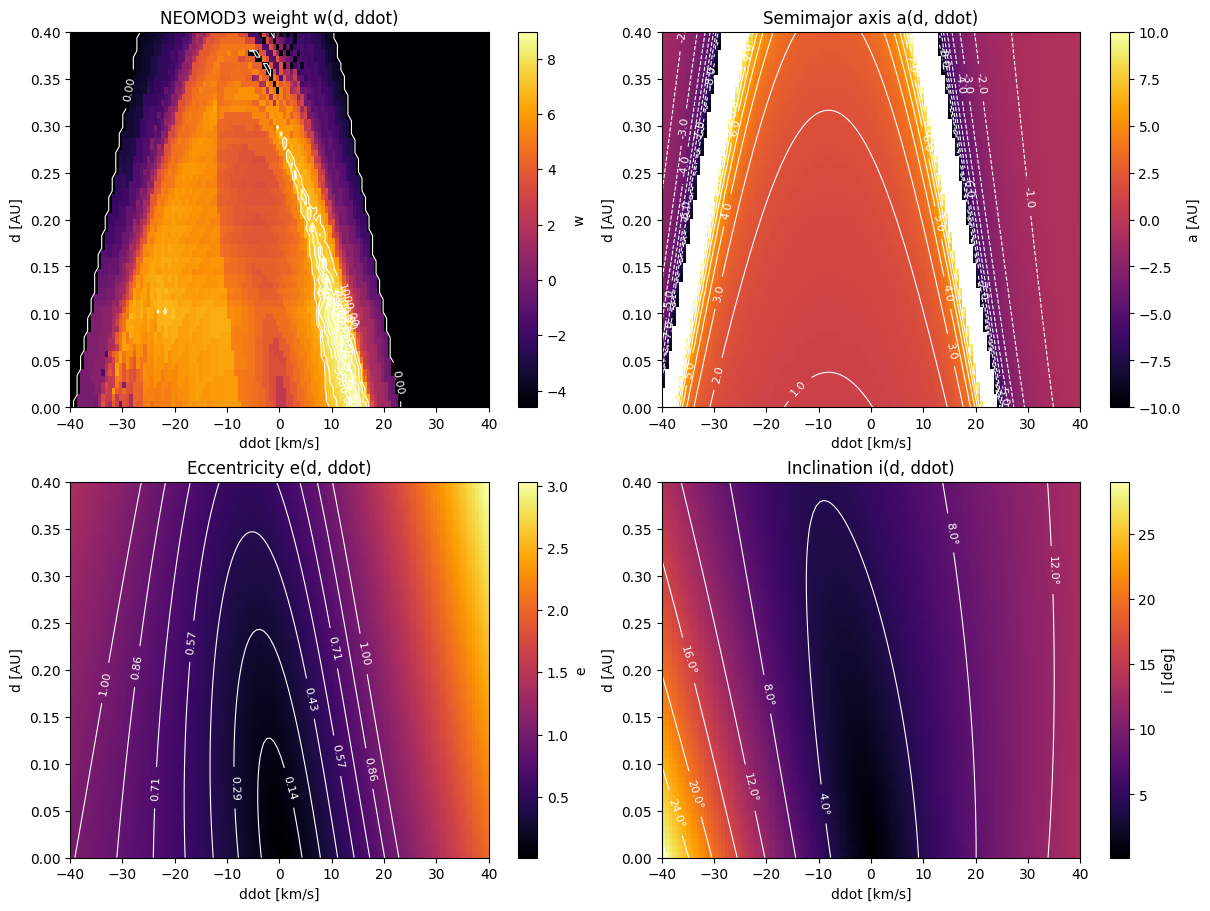

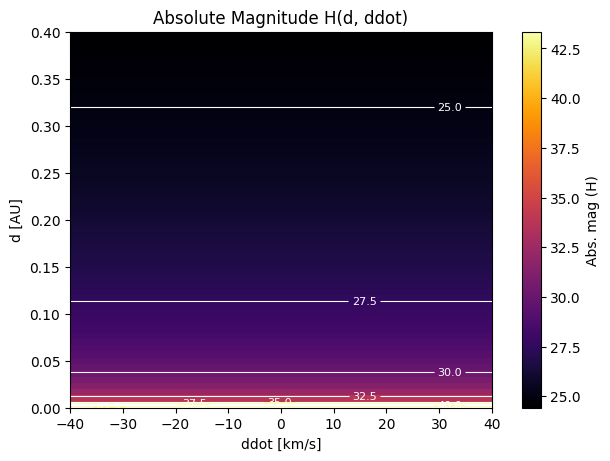

In [8]:
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import matplotlib.pyplot as plt

d_vals = np.linspace(0.00, 0.40,60)   
v_vals = np.linspace(-40.0, 40.0, 120)    


W = np.zeros((len(d_vals), len(v_vals)))   
A = np.zeros_like(W)                       
E = np.zeros_like(W)                       
I = np.zeros_like(W)   
H = np.zeros_like(W) 


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0= nf.compute_neomod3_weight(d, v, l_hat, v_hat, mag, obstime,
                           rE, vE, r_obs,
                           array4D, H_center, a_center, e_center, i_center) 
        H_0 = np.asarray(H_0).squeeze()
        
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i,j] = np.asarray(H_0).item()


fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d

im0 = axs[0, 0].imshow(np.log(W + 0.01), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("NEOMOD3 weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")

fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(
    A_mask,
    origin="lower",
    extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
    aspect="auto",
    cmap="inferno",
    norm=norm,
)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

#eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

#inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

#absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

#### this is with the full version of s3m

In [9]:
s3m = sm.define_s3m()
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [10]:
s3m_full = smfull.define_s3m()

['S0.s3m', 'S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m', 'SH.s3m', 'SI.s3m', 'SJ.s3m', 'SL.s3m', 'SR.s3m', 'SS.s3m', 'ST.s3m', 'St5.s3m']
The final df is done.


In [20]:
s3m,array4D_s3mfull, H_center_s3mfull, a_center_s3mfull, e_center_s3mfull, i_center_s3mfull = sm.s3m_array(s3m)

In [21]:
# Initialize the scorer once with the 4D grid to use it
scorer_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

result_s3m = scorer.compute_score(
    obstime_str="2025-09-23T00:00:00",
    ra_deg=359.9, dec_deg=-0.07,
    dra_deg_per_day=-0.188316, ddec_deg_per_day=-0.08016,
    mag=21.0,
    d_au=0, ddot_kms=3.0
)

print(f"Score: {result_s3m['score']}")
print(f"a: {result_s3m['a']}")
print(f"e: {result_s3m['e']}")
print(f"i: {result_s3m['i']}")
print(f"H: {result_s3m['H']}")

Score: 33.111
a: 1.0002018491964548
e: 0.07930526378609722
i: 0.009235168551452308
H: 40.346493183683194


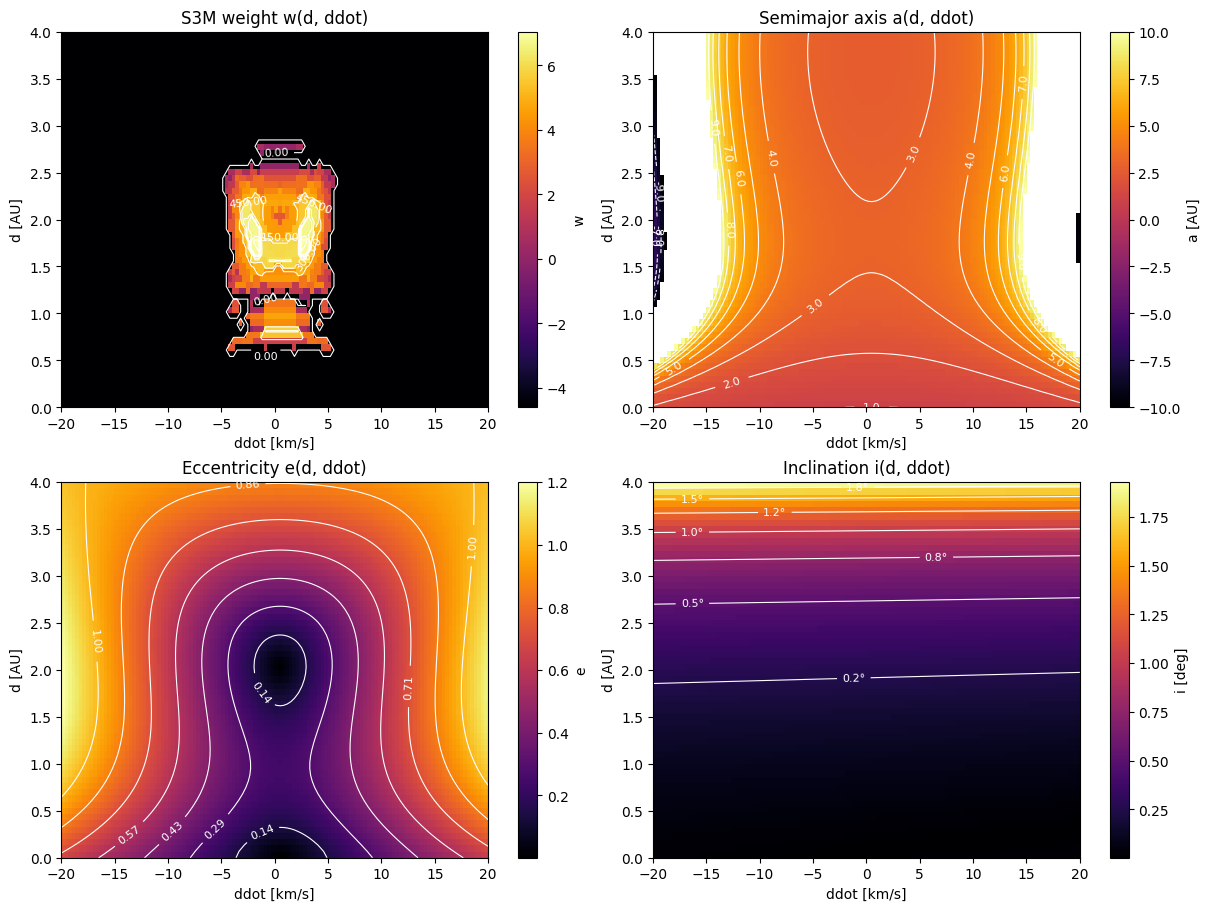

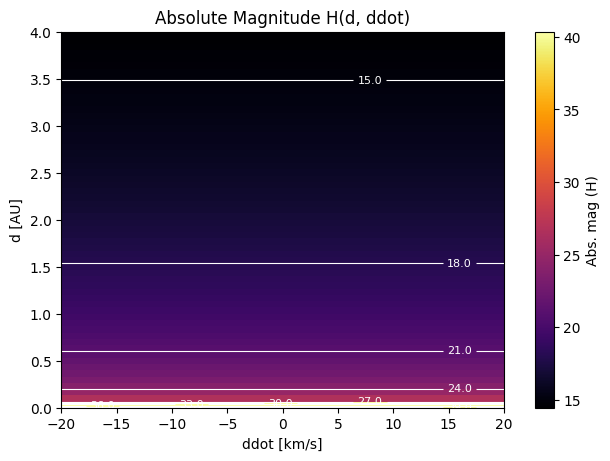

In [13]:
from matplotlib.colors import TwoSlopeNorm

# Define the grid
d_min, d_max, Nd = 0.00, 4.0, 60
v_min, v_max, Nv = -20.0, 20.0, 120
d_vals = np.linspace(d_min, d_max, Nd)
v_vals = np.linspace(v_min, v_max, Nv)

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra_deg, dec_deg = 359.9, -0.07
dra_deg_per_day, ddec_deg_per_day = -0.188316, -0.08016
mag = 21.0

# Computes the grids
W = np.zeros((Nd, Nv))
A = np.zeros((Nd, Nv))
E = np.zeros((Nd, Nv))
I = np.zeros((Nd, Nv))
H = np.zeros((Nd, Nv))

for i, d_au in enumerate(d_vals):
    for j, ddot_kms in enumerate(v_vals):
        result = scorer_s3m.compute_score(
            obstime_str, ra_deg, dec_deg,
            dra_deg_per_day, ddec_deg_per_day, mag,
            d_au, ddot_kms
        )
        W[i, j] = result['score']
        A[i, j] = result['a']
        E[i, j] = result['e']
        I[i, j] = result['i']
        H[i, j] = result['H']

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]

im0 = axs[0, 0].imshow(np.log(W + 1e-2), origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont0 = axs[0,0].contour(v_vals, d_vals, W, levels=8, colors='white', linewidths=0.8)
axs[0,0].clabel(cont0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set_title("S3M weight w(d, ddot)")
axs[0, 0].set_xlabel("ddot [km/s]")
axs[0, 0].set_ylabel("d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# Semimajor axis
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")
A_mask = np.ma.masked_where(np.abs(A) > 10, A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
ax = axs[0, 1]
im = ax.imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
ax.set_title("Semimajor axis a(d, ddot)")
ax.set_xlabel("ddot [km/s]")
ax.set_ylabel("d [AU]")
fig.colorbar(im, ax=ax, label="a [AU]")
levels = np.linspace(-10, 10, 21)
cs = ax.contour(X, Y, A_mask, levels=levels, colors="white", linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

# Eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont2 = axs[1,0].contour(v_vals, d_vals, E, levels=np.linspace(0, 1, 8), colors='white', linewidths=0.8)
axs[1,0].clabel(cont2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set_title("Eccentricity e(d, ddot)")
axs[1, 0].set_xlabel("ddot [km/s]")
axs[1, 0].set_ylabel("d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# Inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cont3 = axs[1,1].contour(v_vals, d_vals, I, levels=8, colors='white', linewidths=0.8)
axs[1,1].clabel(cont3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set_title("Inclination i(d, ddot)")
axs[1, 1].set_xlabel("ddot [km/s]")
axs[1, 1].set_ylabel("d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# Absolute magnitude
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
contH = axH.contour(v_vals, d_vals, H, levels=8, colors='white', linewidths=0.8)
axH.clabel(contH, inline=True, fontsize=8, fmt="%.1f")
axH.set_title("Absolute Magnitude H(d, ddot)")
axH.set_xlabel("ddot [km/s]")
axH.set_ylabel("d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()

In [10]:
neo_s3m = neo3m.define_s3m()

['S0.s3m']
The final df is done.


In [11]:
neo_s3m,array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = neo3m.s3m_array(neo_s3m)

In [12]:
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [1:41:16<00:00, 196.03s/it]

Computation complete!


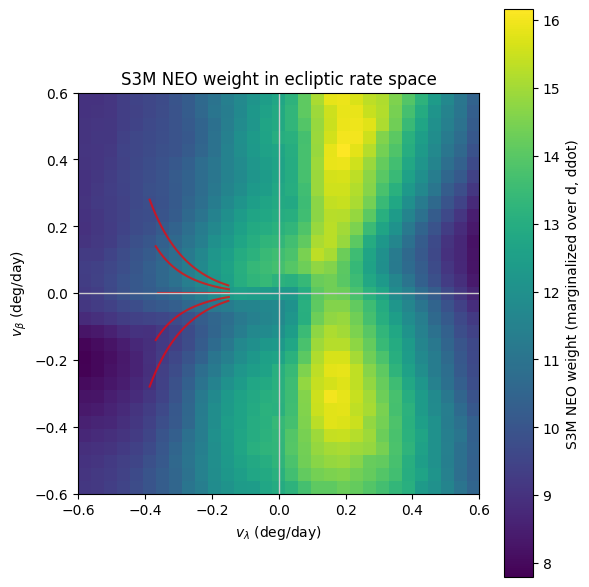

In [13]:
import sys
sys.path.insert(0, "src")
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation parameters
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 10.0, 20.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates(
                ra0_deg, dec0_deg, vlam, vbet
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_neo_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals


print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M NEO weight in ecliptic rate space")
plt.tight_layout()
plt.show()

In [14]:
print(np.percentile(vlam, [1, 5, 50, 95, 99]))

[-0.15093045 -0.15093045 -0.15093045 -0.15093045 -0.15093045]


In [15]:
print("neg/pos", (vlam<0).sum(), (vlam>0).sum())

neg/pos 1 0


Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [1:42:21<00:00, 198.10s/it]


Computation complete!


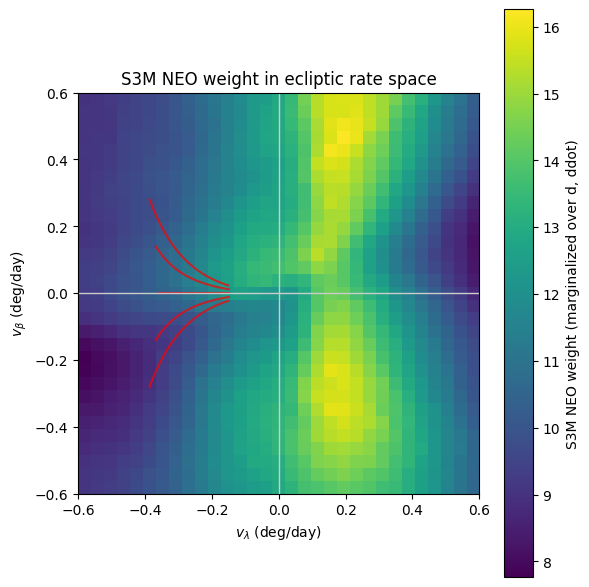

In [26]:
import sys
sys.path.insert(0, "src")
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 10.0, 20.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    

    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_neo_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals


print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M NEO weight in ecliptic rate space")
plt.tight_layout()
plt.show()